In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

1. ini pakai head karena disuruhnya 5 data paling atas, kalo pake sample ntar random :v 

In [5]:

df = pd.read_csv('Mall_Customers.csv');
print('5 data atas anjay : ')
print(df.head());

5 data atas anjay : 
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


2. karena disuruhnya cuma nampilin annual income, sama spending score (1-100), jadinya yang dipanggil di data frame cuma 2 itu, kalo yang bawah bawahnya itu sekalian standarisasi pake rumus di modul, kek sekalian aja gitu biar g banyak tempat :P

In [6]:
Customers = df[['Annual Income (k$)', 'Spending Score (1-100)']];

scaler = StandardScaler();
X_scaled = scaler.fit_transform(Customers);

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10);
df['cluster'] = kmeans.fit_predict(X_scaled);

print(df.head());

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


3. ini mencari elbow nya, pake rumus yang di modul dan di praktikum pas itu, terus kita liat nich elbownya yang paling optimal berapa (ternyata 5)...

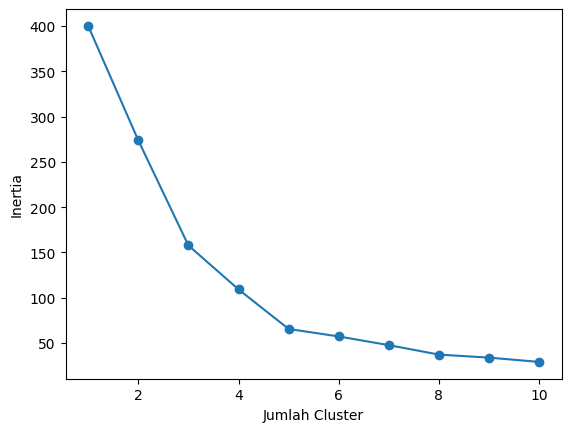

In [7]:
inertia = [];
k_range = range(1, 11);
for k in k_range:
    model = KMeans(n_clusters=k);
    model.fit(X_scaled);
    inertia.append(model.inertia_);

plt.plot(k_range, inertia,marker='o');
plt.xlabel('Jumlah Cluster');
plt.ylabel('Inertia');
plt.show();

5. karena elbow nya 5 (n_clusters), kita coba terapin si K-means Clustering ini, random state sama n_init nya kalo kata mas yusuf random aja tapi jangan terlau besar sama janga terlalu kecil 

In [8]:
K_Means = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10);

df['cluster'] = K_Means.fit_predict(X_scaled);

print(df.head());

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


6. ini nampilin segmentasi steleha K-Menas Clustering, aku pake beberapa tambahan biar keren aja ye kan xixixixi

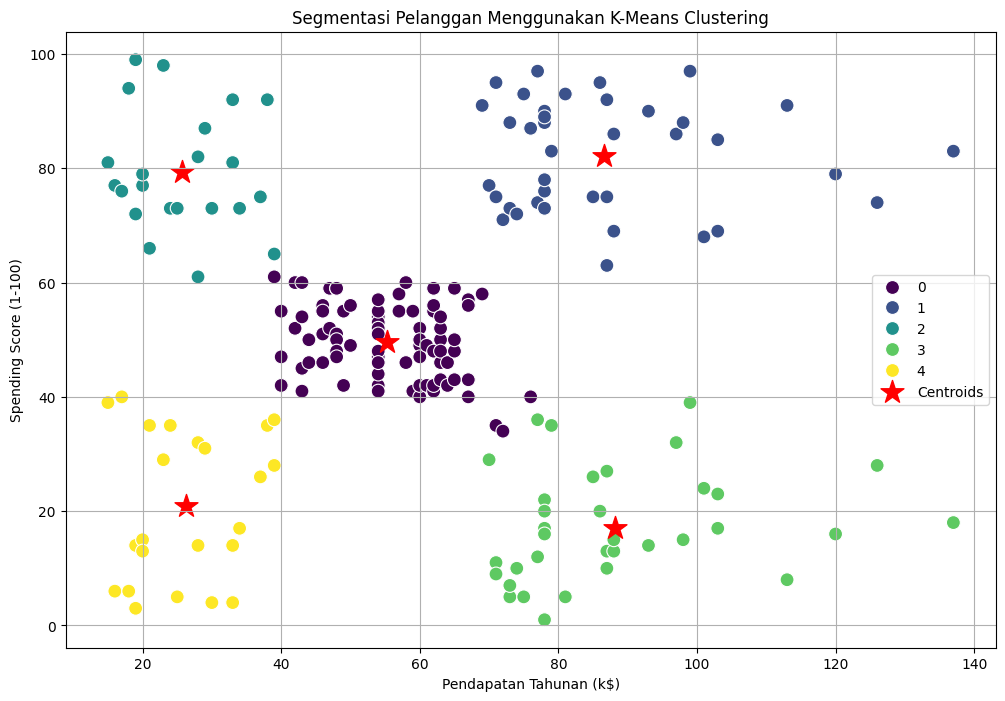

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


In [9]:
plt.figure(figsize=(12, 8));
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='cluster', data=df, palette='viridis', s=100);

centroids = scaler.inverse_transform(K_Means.cluster_centers_);
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='*', label='Centroids');

plt.title('Segmentasi Pelanggan Menggunakan K-Means Clustering');
plt.xlabel('Pendapatan Tahunan (k$)');
plt.ylabel('Spending Score (1-100)');
plt.legend();
plt.grid(True);
plt.show();

print(df.head());

7. NAH INI NIH JUJUR AE MAS PAS ITU G BEGITU PAHAM HAHA, tapi setelah GPT mayan paham sih, awalnya biasa y kan dipnaggil df nnya dulu, nah ternyata yang ngasih apa tuh mas, intperestasi karateristik pake if els, y bener sih pake itu jadi jika cluster nya lebih dikit berarti dia kemana, kalo lebih besar dia ke mana, di kategorikan gitu y kan. Kalo kemaren gpt pas di praktikum g  tau dah g paham mas itu kenapa bisa gitu :V

In [ ]:
cluster_summary = df.groupby("cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()
print("Rata-rata tiap cluster:")
print(cluster_summary)

def segment_label(row):
    if row['cluster'] == 0:
        return "Pelanggan Hemat (Low Income, Low Spending)"
    elif row['cluster'] == 1:
        return "Pelanggan Potensial (High Income, Low Spending)"
    elif row['cluster'] == 2:
        return "Pelanggan Premium (High Income, High Spending)"
    elif row['cluster'] == 3:
        return "Pelanggan Muda Aktif (Low Income, High Spending)"
    else:
        return "Pelanggan Rata-rata (Mid Income, Mid Spending)"

df["Segment"] = df.apply(segment_label, axis=1)

print("\nData dengan Segmen:")
print(df[["CustomerID", "Annual Income (k$)", "Spending Score (1-100)", "cluster", "Segment"]].head(10))

Rata-rata tiap cluster:
         Annual Income (k$)  Spending Score (1-100)
cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043

Data dengan Segmen:
   CustomerID  Annual Income (k$)  Spending Score (1-100)  cluster  \
0           1                  15                      39        4   
1           2                  15                      81        2   
2           3                  16                       6        4   
3           4                  16                      77        2   
4           5                  17                      40        4   
5           6                  17                      76        2   
6           7                  18                       6        4   
7           8                  

8. ini disuruh buat strategi rekomen pasar berdassarkan clusteringnnya, dibuat dict strategi dulu kayak group by gitu dari 0 - 4. Terus panggil lah df nya tapi dibikin segment yang kek nomor 7, soalnya kan mau dibuat strategi. naah baru pake head supaya strategi terbaik itu ditampilkan, karena yang paling atas

In [ ]:
strategi = {
    0: "Promo hemat, diskon bundling, loyalty card sederhana",
    1: "Upselling & cross-selling, layanan eksklusif, edukasi nilai produk",
    2: "Produk premium & eksklusif, membership VIP, event experience",
    3: "Produk trendi & fashionable, promosi media sosial, cicilan/BNPL",
    4: "Paket value for money, promo musiman, program loyalitas keluarga"
}

strategi_df = pd.DataFrame({
    "Cluster": strategi.keys(),
    "Segment": [
        "Pelanggan Hemat (Low Income, Low Spending)",
        "Pelanggan Potensial (High Income, Low Spending)",
        "Pelanggan Premium (High Income, High Spending)",
        "Pelanggan Muda Aktif (Low Income, High Spending)",
        "Pelanggan Rata-rata (Mid Income, Mid Spending)"
    ],
    "Strategi Pemasaran": strategi.values()
})

print("\n R ekomendasi Strategi Pemasaran Berdasarkan Cluster:")
print(strategi_df)

df["Strategi"] = df["cluster"].map(strategi)
print("\nData pelanggan dengan strategi pemasaran:")
print(df[["CustomerID", "Annual Income (k$)", "Spending Score (1-100)", "cluster", "Segment", "Strategi"]].head(10))


📊 Rekomendasi Strategi Pemasaran Berdasarkan Cluster:
   Cluster                                           Segment  \
0        0        Pelanggan Hemat (Low Income, Low Spending)   
1        1   Pelanggan Potensial (High Income, Low Spending)   
2        2    Pelanggan Premium (High Income, High Spending)   
3        3  Pelanggan Muda Aktif (Low Income, High Spending)   
4        4    Pelanggan Rata-rata (Mid Income, Mid Spending)   

                                  Strategi Pemasaran  
0  Promo hemat, diskon bundling, loyalty card sed...  
1  Upselling & cross-selling, layanan eksklusif, ...  
2  Produk premium & eksklusif, membership VIP, ev...  
3  Produk trendi & fashionable, promosi media sos...  
4  Paket value for money, promo musiman, program ...  

Data pelanggan dengan strategi pemasaran:
   CustomerID  Annual Income (k$)  Spending Score (1-100)  cluster  \
0           1                  15                      39        4   
1           2                  15              